## Local Inference on GPU
Model page: https://huggingface.co/timm/mobilenetv3_small_100.lamb_in1k

⚠️ If the generated code snippets do not work, please open an issue on either the [model repo](https://huggingface.co/timm/mobilenetv3_small_100.lamb_in1k)
			and/or on [huggingface.js](https://github.com/huggingface/huggingface.js/blob/main/packages/tasks/src/model-libraries-snippets.ts) 🙏

In [1]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

In [2]:
!pip install tensorflow tensorflow-datasets torch torchvision datasets

In [41]:
from datasets import load_dataset, DatasetDict, load_from_disk
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics.pairwise import cosine_similarity
import pandas, numpy, seaborn as sns, matplotlib.pyplot as plt
import tensorflow_datasets as tfds
import tensorflow as tf
import json, shutil, os, timm, random
random.seed(42)  # for reproducibility

from PIL import Image
from google.colab import files
from huggingface_hub import notebook_login

import torch
from torchvision import transforms
import torch.nn as nn
import torchvision.models as models
from torchvision.datasets import SUN397
from torch.utils.data import Subset
from torch.utils.data import DataLoader

import hashlib
from collections import defaultdict

# **DATA LOADING AND PREPROCESSING**

In [4]:
#LOADING THREE PRETRAINED NEURAL NETWORKS TO FINE-TUNE
model_mob = timm.create_model("hf_hub:timm/mobilenetv3_small_100.lamb_in1k", pretrained=True)
model_eff = timm.create_model("hf_hub:timm/efficientnet_b0.ra_in1k", pretrained=True)
model_res = timm.create_model("hf_hub:timm/resnet18.a1_in1k", pretrained=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/586 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/10.2M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/578 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/755 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/46.8M [00:00<?, ?B/s]

In [5]:
#LOAD SUN397 DATABASE
dataset = load_dataset("tanganke/sun397")  # downloads from Hugging Face
print(dataset)

#READ LABELS TO PICK SUBSET
feature = dataset["train"].features["label"]
print(feature.names)       # first 50 class names
print(len(feature.names))       # should be 397

README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

...

data/test-00016-of-00018.parquet:   0%|          | 0.00/424M [00:00<?, ?B/s]

data/test-00017-of-00018.parquet:   0%|          | 0.00/366M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/19850 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/19850 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 19850
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 19850
    })
})
['abbey', 'airplane cabin', 'airport terminal', 'alley', 'amphitheater', 'amusement arcade', 'amusement park', 'anechoic chamber', 'apartment building outdoor', 'apse indoor', 'aquarium', 'aqueduct', 'arch', 'archive', 'arrival gate outdoor', 'art gallery', 'art school', 'art studio', 'assembly line', 'athletic field outdoor', 'atrium public', 'attic', 'auditorium', 'auto factory', 'badlands', 'badminton court indoor', 'baggage claim', 'bakery shop', 'balcony exterior', 'balcony interior', 'ball pit', 'ballroom', 'bamboo forest', 'banquet hall', 'bar', 'barn', 'barndoor', 'baseball field', 'basement', 'basilica', 'basketball court outdoor', 'bathroom', 'batters box', 'bayou', 'bazaar indoor', 'bazaar outdoor', 'beach', 'beauty salon', 'bedroom', 'berth', 'biology laboratory', 'bistro indoor', 

In [6]:
#THE TEN CLASSES TO TRAIN ON
classes = [
    "slum",
    "botanical garden",
    "arch",
    "volleyball court outdoor",
    "drugstore",
    "dentists office",
    "cottage garden",
    "cafeteria",
    "volcano",
    "boardwalk",
    "temple east asia",
    "playground",
    "bazaar indoor",
    "restaurant patio",
    "lake natural",
    "art school",
    "art gallery",
    "beauty salon",
    "corn field",
    "creek",
]


In [7]:
#FILTERS DATASET TO GRAB SUBSET
dataset = load_dataset("tanganke/sun397")  # downloads once and caches locally

# Inspect label names
id_to_label = dataset["train"].features["label"].int2str
label_to_id = dataset["train"].features["label"].str2int

class_ids = [label_to_id(name) for name in classes]

# Filter to keep only the chosen 10 classes
def selected_classes(example):
    return example["label"] in class_ids

train_ds = dataset["train"].filter(selected_classes)
val_ds   = dataset["validation"].filter(selected_classes) if "validation" in dataset else dataset["test"].filter(selected_classes)

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

Filter:   0%|          | 0/19850 [00:00<?, ? examples/s]

Filter:   0%|          | 0/19850 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


In [8]:
#CACHE SUBSET AND SAVE LOCALLY
subset = DatasetDict({
    "train": train_ds,
    "validation": val_ds,   # or "test" if that’s what you used
})

print(len(dataset["train"]), len(dataset["test"]))

subset.save_to_disk("sun_subset_10")
dataset.save_to_disk("sun_dataset")

!zip -r sun_subset_10.zip sun_subset_10
!zip -r sun_dataset.zip sun_dataset
files.download("sun_subset_10.zip")

19850 19850


Saving the dataset (0/1 shards):   0%|          | 0/1000 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/1000 [00:00<?, ? examples/s]

Saving the dataset (0/15 shards):   0%|          | 0/19850 [00:00<?, ? examples/s]

Saving the dataset (0/15 shards):   0%|          | 0/19850 [00:00<?, ? examples/s]

  adding: sun_subset_10/ (stored 0%)
  adding: sun_subset_10/dataset_dict.json (stored 0%)
  adding: sun_subset_10/validation/ (stored 0%)
  adding: sun_subset_10/validation/state.json (deflated 38%)
  adding: sun_subset_10/validation/dataset_info.json (deflated 80%)
  adding: sun_subset_10/validation/data-00000-of-00001.arrow (deflated 2%)
  adding: sun_subset_10/train/ (stored 0%)
  adding: sun_subset_10/train/state.json (deflated 37%)
  adding: sun_subset_10/train/dataset_info.json (deflated 80%)
  adding: sun_subset_10/train/data-00000-of-00001.arrow (deflated 2%)
  adding: sun_dataset/ (stored 0%)
  adding: sun_dataset/dataset_dict.json (stored 0%)
  adding: sun_dataset/train/ (stored 0%)
  adding: sun_dataset/train/data-00004-of-00015.arrow (deflated 1%)
  adding: sun_dataset/train/data-00008-of-00015.arrow (deflated 2%)
  adding: sun_dataset/train/data-00001-of-00015.arrow (deflated 1%)
  adding: sun_dataset/train/data-00013-of-00015.arrow (deflated 1%)
  adding: sun_dataset/tra

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [10]:
#HANDLES IMAGE TENSOR TRANSFORMATIONS AND CLASS MAPPING
class Dataset_Transform(torch.utils.data.Dataset):
    def __init__(self, hf_split, transform, easy_ids, id2label, label2id):
        self.ds = hf_split
        self.transform = transform
        self.easy_ids = set(easy_ids)
        # build compact 0–9 labels
        self.old2new = {old: new for new, old in enumerate(easy_ids)}

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        ex = self.ds[idx]
        img = ex["image"]
        if not isinstance(img, Image.Image):
            img = Image.fromarray(img)
        img = img.convert("RGB")
        y_old = ex["label"]
        y = self.old2new[y_old]
        img = self.transform(img)
        return img, y

In [11]:
def make_embedder(trained_model, device):
  """Deep copy a trained classifier and strip its head for 512-dim feature extraction."""
  model = copy.deepcopy(trained_model)
  model.fc = nn.Identity()
  model.eval()

  model = model.to(device)

  return model

In [12]:
def make_embed_transform(img_size=224):
  """Return a deterministic val-style transform (no augmentation)."""
  return transforms.Compose([
      transforms.Resize((img_size, img_size)),
      transforms.ToTensor(),
      transforms.Normalize([0.485, 0.456, 0.406],
                            [0.229, 0.224, 0.225])
  ])

In [13]:
def stratified_sample(hf_split, n_per_class=50, seed=42):
  """
  Return a list of indices sampled evenly across all label classes.
  Warns if any class has fewer than n_per_class examples.
  """
  random.seed(seed)
  indices = defaultdict(list)
  for i, item in enumerate(hf_split):
      indices[item["label"]].append(i)

  balanced_idx = []
  for label_id, cls_idx in indices.items():
      if len(cls_idx) < n_per_class:
          print(f"Warning: Class {label_id} only has {len(cls_idx)} samples — using all")
      shuffled = cls_idx.copy()
      random.shuffle(shuffled)
      balanced_idx.extend(shuffled[:n_per_class])

  print(f"Sampled {len(balanced_idx)} images across {len(indices)} classes")
  return balanced_idx

In [14]:
def extract_features(trained_model, hf_split, balanced_idx,
                     class_ids, id_to_label, label_to_id, device,
                     batch_size=32):
  """
  Build a DataLoader from the sampled indices and extract
  512-dim embeddings in batches. Returns (features, labels).
    features — numpy array (N, 512)
    labels   — list of compact 0–9 ints
  """
  embedder = make_embedder(trained_model, device)
  transform = make_embed_transform()

  sample_dataset = Dataset_Transform(
      hf_split.select(balanced_idx),
      transform,
      class_ids, id_to_label, label_to_id
  )
  loader = DataLoader(sample_dataset, batch_size=batch_size, shuffle=False)

  features, labels = [], []
  with torch.no_grad():
      for imgs, lbls in loader:
          feats = embedder(imgs.to(device))
          features.append(feats.cpu().numpy())
          labels.extend(lbls.numpy())

  features = numpy.vstack(features)
  print(f"Features shape: {features.shape}")   # (N, 512)
  return features, labels

In [15]:
def compute_class_means(features, labels, hf_split, class_ids):
  """
  Average embeddings per class. Returns a DataFrame of shape (10, 512)
  indexed by human-readable class name strings.
  """
  class_names_all = hf_split.features["label"].names
  label_names = [class_names_all[class_ids[l]] for l in labels]

  df = pandas.DataFrame(features)
  df["label"] = label_names
  class_means = df.groupby("label").mean()    # (10, 512)
  print(f"Class means shape: {class_means.shape}")
  return class_means


In [16]:
def plot_cosine_similarity(class_means, title="Per-Class Cosine Similarity (ResNet18 mean embeddings)"):
  """Compute and plot a per-class cosine similarity heatmap."""
  from sklearn.metrics.pairwise import cosine_similarity

  cos_sim = cosine_similarity(class_means)
  sim_df = pandas.DataFrame(
      cos_sim,
      index=class_means.index,
      columns=class_means.index
  )

  plt.figure(figsize=(14, 12))
  sns.heatmap(
      sim_df, cmap="YlOrRd", annot=True, fmt=".2f",
      xticklabels=True, yticklabels=True,
      linewidths=0.3, linecolor="gray", annot_kws={"size": 7}
  )
  plt.title(title)
  plt.xticks(rotation=90, fontsize=7)
  plt.yticks(rotation=0, fontsize=7)
  plt.tight_layout()
  plt.show()

  return sim_df

In [17]:
def check_data_integrity(subset):
  """
  Detect exact duplicate images within and across the train/validation splits.

  Hashes every image using MD5 after resizing to 64×64 RGB to normalise
  minor encoding differences. Groups matching hashes and categorises them
  into three buckets:
    - train↔validation duplicates : same image in both splits (data leakage)
    - train-only duplicates        : same image appears twice in train
    - validation-only duplicates   : same image appears twice in validation

  Args:
      subset (DatasetDict): HuggingFace DatasetDict with "train" and "validation" splits.

  Returns:
      dict with keys "train_val", "train_train", "val_val" —
      each a list of duplicate entry groups.
  """

  hash_map = defaultdict(list)  # md5 hex → list of ("split", index) tuples

  # Hash every train image
  for i, item in enumerate(subset["train"]):
      img = item["image"].convert("RGB").resize((64, 64))
      h = hashlib.md5(img.tobytes()).hexdigest()
      hash_map[h].append(("train", i))

  # Hash every validation image into the same map so cross-split matches surface
  for i, item in enumerate(subset["validation"]):
      img = item["image"].convert("RGB").resize((64, 64))
      h = hashlib.md5(img.tobytes()).hexdigest()
      hash_map[h].append(("validation", i))

  train_val_dupes   = []  # leakage  — same image in both splits
  train_train_dupes = []  # redundancy — duplicate within train
  val_val_dupes     = []  # redundancy — duplicate within validation

  for h, entries in hash_map.items():
      if len(entries) < 2:
          continue  # unique image — skip

      splits = [e[0] for e in entries]
      has_train = "train"      in splits
      has_val   = "validation" in splits

      if has_train and has_val:
          train_val_dupes.append(entries)       # data leakage
      elif splits.count("train") > 1:
          train_train_dupes.append(entries)     # duplicate in train only
      elif splits.count("validation") > 1:
          val_val_dupes.append(entries)         # duplicate in validation only

  # Print summary
  print(f"Train↔Validation duplicates (data leakage): {len(train_val_dupes)}")
  print(f"Train-only duplicates:                       {len(train_train_dupes)}")
  print(f"Validation-only duplicates:                  {len(val_val_dupes)}")

  if len(train_val_dupes) == 0:
      print("No cross-split leakage detected.")
  else:
      print(f"Warning: {len(train_val_dupes)} images appear in both splits — consider removing them from training.")

  return {
      "train_val":   train_val_dupes,
      "train_train": train_train_dupes,
      "val_val":     val_val_dupes,
  }

In [18]:
results = check_data_integrity(subset)

Train↔Validation duplicates (data leakage): 0
Train-only duplicates:                       0
Validation-only duplicates:                  0
No cross-split leakage detected.


# **MODEL TRAINING**

In [19]:
#LOAD FULL DATASET OR SUBSET FROM COLAB FILES
subset = load_from_disk("/content/sun_subset_10")
train_ds = subset["train"]
val_ds   = subset["validation"]

In [20]:
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = 20

In [21]:
#TRANSFORM TRAINING AND VALIDATION DATA INTO 224X224 TENSORS WITH RGB
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

In [22]:
train_data = Dataset_Transform(train_ds, train_transform, class_ids, id_to_label, label_to_id)
val_data   = Dataset_Transform(val_ds, val_transform, class_ids, id_to_label, label_to_id)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

In [23]:
#BUILD CLASSIFIERS USING PRETRAINED NETWORKS
def build_resnet18(num_classes=NUM_CLASSES, freeze_backbone=False):
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    if freeze_backbone:
        for p in model.parameters():
            p.requires_grad = False
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    return model.to(device)

def build_efficientnet_b0(num_classes=NUM_CLASSES, freeze_backbone=False):
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
    if freeze_backbone:
        for p in model.parameters():
            p.requires_grad = False
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, num_classes)
    return model.to(device)

def build_mobilenet_v3(num_classes=NUM_CLASSES, freeze_backbone=False):
    model = models.mobilenet_v3_large(weights=models.MobileNet_V3_Large_Weights.IMAGENET1K_V1)
    if freeze_backbone:
        for p in model.parameters():
            p.requires_grad = False
    in_features = model.classifier[3].in_features
    model.classifier[3] = nn.Linear(in_features, num_classes)
    return model.to(device)

In [24]:
def plot_normalized_confusion_matrix(model, data_loader, class_names, title="Normalized Confusion Matrix"):
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for imgs, labels in data_loader:
            imgs = imgs.to(device)
            labels = labels.to(device)

            outputs = model(imgs)
            preds = torch.argmax(outputs, dim=1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=list(range(len(class_names))),
        normalize="true"
    )

    fig, ax = plt.subplots(figsize=(10, 8))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap="Blues", ax=ax, xticks_rotation=45, values_format=".2f", colorbar=True)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

    return cm

In [25]:
def train_one_model(model, train_loader, val_loader, epochs=10, lr=1e-3, patience=3):
    """
    Train a single PyTorch model with Adam optimiser, LR scheduling, and early stopping.

    Training runs for up to `epochs` epochs. After each epoch, the validation
    accuracy is passed to ReduceLROnPlateau, which reduces the learning rate by
    10× if no improvement is seen for `patience` consecutive epochs. If val_acc
    still does not improve after another `patience` epochs, training stops early.
    The model is restored to its best validation weights before returning.

    Args:
        model        (nn.Module)    : PyTorch model to train (already on correct device).
        train_loader (DataLoader)   : DataLoader for the training split.
        val_loader   (DataLoader)   : DataLoader for the validation split.
        epochs       (int)          : Maximum number of training epochs. Default: 10.
        lr           (float)        : Initial learning rate for Adam. Default: 1e-3.
                                      Recommended: 1e-3 for ResNet18/MobileNetV3,
                                                   3e-4 for EfficientNet-B0.
        patience     (int)          : Epochs without val_acc improvement before
                                      LR is reduced AND early stopping triggers. Default: 3.

    Returns:
        nn.Module: The model loaded with the weights from the best validation epoch.
    """
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), lr=lr
    )

    # Reduce LR by 0.1 if val_acc plateaus for `patience` epochs
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.1, patience=patience
    )

    # Early stopping state
    best_val_acc      = 0.0
    best_weights      = None
    epochs_no_improve = 0

    for epoch in range(epochs):

        # ── Training ──
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * imgs.size(0)
            _, preds = outputs.max(1)
            correct += preds.eq(labels).sum().item()
            total   += labels.size(0)

        train_loss = running_loss / total
        train_acc  = correct / total

        # ── Validation ──
        model.eval()
        val_correct, val_total = 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                _, preds = outputs.max(1)
                val_correct += preds.eq(labels).sum().item()
                val_total   += labels.size(0)

        val_acc    = val_correct / val_total
        current_lr = optimizer.param_groups[0]["lr"]
        print(f"Epoch {epoch+1}/{epochs} | loss={train_loss:.4f} | "
              f"train_acc={train_acc:.3f} | val_acc={val_acc:.3f} | lr={current_lr:.2e}")

        # Step scheduler on val_acc — fires LR reduction if plateau detected
        scheduler.step(val_acc)

        # Save best weights; increment no-improve counter otherwise
        if val_acc > best_val_acc:
            best_val_acc      = val_acc
            best_weights      = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"⏹ Early stopping at epoch {epoch+1} "
                      f"— no improvement for {patience} epochs")
                break

    # Restore best checkpoint before returning
    model.load_state_dict(best_weights)
    print(f"Best val_acc: {best_val_acc:.3f}")
    return model

In [26]:
def run_two_phase(build_fn, train_loader, val_loader, lr_head=1e-3, lr_full=1e-4):
    """Two-phase training: warm up head, then fine-tune full network."""

    # Phase 1 — head only
    model = build_fn(freeze_backbone=True)
    print("── Phase 1: Head warm-up ──")
    model = train_one_model(model, train_loader, val_loader,
                            epochs=5, lr=lr_head, patience=5)

    # Phase 2 — full fine-tune
    for p in model.parameters():
        p.requires_grad = True
    print("── Phase 2: Full fine-tune ──")
    model = train_one_model(model, train_loader, val_loader,
                            epochs=25, lr=lr_full, patience=8)

    return model

In [27]:
print(f"NUM_CLASSES = {NUM_CLASSES}")
print(f"len(classes) = {len(classes)}")
print(f"len(class_ids) = {len(class_ids)}")

# Check every label in train_loader is in range
for imgs, labels in train_loader:
    bad = labels[(labels < 0) | (labels >= NUM_CLASSES)]
    if len(bad) > 0:
        print(f"Bad labels: {bad.tolist()}")
        break
else:
    print("All train labels valid")

for imgs, labels in val_loader:
    bad = labels[(labels < 0) | (labels >= NUM_CLASSES)]
    if len(bad) > 0:
        print(f"Bad val labels: {bad.tolist()}")
        break
else:
    print("All val labels valid")


NUM_CLASSES = 20
len(classes) = 20
len(class_ids) = 20
All train labels valid
All val labels valid


In [28]:
#RUN THE TRAINING PROGRAM ON ALL THREE MODELS

#ResNet
print("Training ResNet‑18")
resnet18 = run_two_phase(build_resnet18, train_loader, val_loader)

#EfficentNet
print("Training EfficientNet‑B0")
efficientnet_b0 = run_two_phase(build_efficientnet_b0, train_loader, val_loader, lr_full = 5e-5)

#MobileNet
print("Training MobileNetV3")
mobilenet_v3 = run_two_phase(build_mobilenet_v3, train_loader, val_loader)

Training ResNet‑18
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 165MB/s]


── Phase 1: Head warm-up ──
Epoch 1/5 | loss=2.5327 | train_acc=0.231 | val_acc=0.532 | lr=1.00e-03
Epoch 2/5 | loss=1.6265 | train_acc=0.612 | val_acc=0.675 | lr=1.00e-03
Epoch 3/5 | loss=1.1728 | train_acc=0.749 | val_acc=0.778 | lr=1.00e-03
Epoch 4/5 | loss=0.9106 | train_acc=0.817 | val_acc=0.796 | lr=1.00e-03
Epoch 5/5 | loss=0.7655 | train_acc=0.844 | val_acc=0.821 | lr=1.00e-03
Best val_acc: 0.821
── Phase 2: Full fine-tune ──
Epoch 1/25 | loss=0.5425 | train_acc=0.861 | val_acc=0.884 | lr=1.00e-04
Epoch 2/25 | loss=0.1347 | train_acc=0.982 | val_acc=0.886 | lr=1.00e-04
Epoch 3/25 | loss=0.0682 | train_acc=0.994 | val_acc=0.880 | lr=1.00e-04
Epoch 4/25 | loss=0.0397 | train_acc=0.998 | val_acc=0.895 | lr=1.00e-04
Epoch 5/25 | loss=0.0356 | train_acc=0.996 | val_acc=0.885 | lr=1.00e-04
Epoch 6/25 | loss=0.0213 | train_acc=1.000 | val_acc=0.892 | lr=1.00e-04
Epoch 7/25 | loss=0.0133 | train_acc=1.000 | val_acc=0.893 | lr=1.00e-04
Epoch 8/25 | loss=0.0092 | train_acc=1.000 | val_ac

100%|██████████| 20.5M/20.5M [00:00<00:00, 150MB/s]


── Phase 1: Head warm-up ──
Epoch 1/5 | loss=2.5773 | train_acc=0.330 | val_acc=0.718 | lr=1.00e-03
Epoch 2/5 | loss=1.7377 | train_acc=0.704 | val_acc=0.763 | lr=1.00e-03
Epoch 3/5 | loss=1.2586 | train_acc=0.782 | val_acc=0.806 | lr=1.00e-03
Epoch 4/5 | loss=0.9912 | train_acc=0.827 | val_acc=0.806 | lr=1.00e-03
Epoch 5/5 | loss=0.8328 | train_acc=0.859 | val_acc=0.825 | lr=1.00e-03
Best val_acc: 0.825
── Phase 2: Full fine-tune ──
Epoch 1/25 | loss=0.6720 | train_acc=0.877 | val_acc=0.850 | lr=5.00e-05
Epoch 2/25 | loss=0.4544 | train_acc=0.924 | val_acc=0.870 | lr=5.00e-05
Epoch 3/25 | loss=0.3528 | train_acc=0.947 | val_acc=0.869 | lr=5.00e-05
Epoch 4/25 | loss=0.2752 | train_acc=0.968 | val_acc=0.880 | lr=5.00e-05
Epoch 5/25 | loss=0.2267 | train_acc=0.972 | val_acc=0.885 | lr=5.00e-05
Epoch 6/25 | loss=0.1699 | train_acc=0.987 | val_acc=0.883 | lr=5.00e-05
Epoch 7/25 | loss=0.1576 | train_acc=0.977 | val_acc=0.888 | lr=5.00e-05
Epoch 8/25 | loss=0.1294 | train_acc=0.991 | val_ac

100%|██████████| 21.1M/21.1M [00:00<00:00, 171MB/s]

── Phase 1: Head warm-up ──


Epoch 1/5 | loss=2.2495 | train_acc=0.436 | val_acc=0.745 | lr=1.00e-03
Epoch 2/5 | loss=1.0910 | train_acc=0.821 | val_acc=0.819 | lr=1.00e-03
Epoch 3/5 | loss=0.7107 | train_acc=0.878 | val_acc=0.837 | lr=1.00e-03
Epoch 4/5 | loss=0.5481 | train_acc=0.903 | val_acc=0.858 | lr=1.00e-03
Epoch 5/5 | loss=0.4432 | train_acc=0.925 | val_acc=0.862 | lr=1.00e-03
Best val_acc: 0.862
── Phase 2: Full fine-tune ──
Epoch 1/25 | loss=0.3162 | train_acc=0.927 | val_acc=0.867 | lr=1.00e-04
Epoch 2/25 | loss=0.1213 | train_acc=0.983 | val_acc=0.881 | lr=1.00e-04
Epoch 3/25 | loss=0.0711 | train_acc=0.992 | val_acc=0.881 | lr=1.00e-04
Epoch 4/25 | loss=0.0465 | train_acc=0.996 | val_acc=0.882 | lr=1.00e-04
Epoch 5/25 | loss=0.0256 | train_acc=1.000 | val_acc=0.885 | lr=1.00e-04
Epoch 6/25 | loss=0.0199 | train_acc=1.000 | val_acc=0.885 | lr=1.00e-04
Epoch 7/25 | loss=0.0217 | train_acc=0.997 | val_acc=0.880 | lr=1.00e-04
Epoch 8/25 | loss=0.0145 | train_acc=0.998 | val_acc=0.887 | lr=1.00e-04
Epoch 

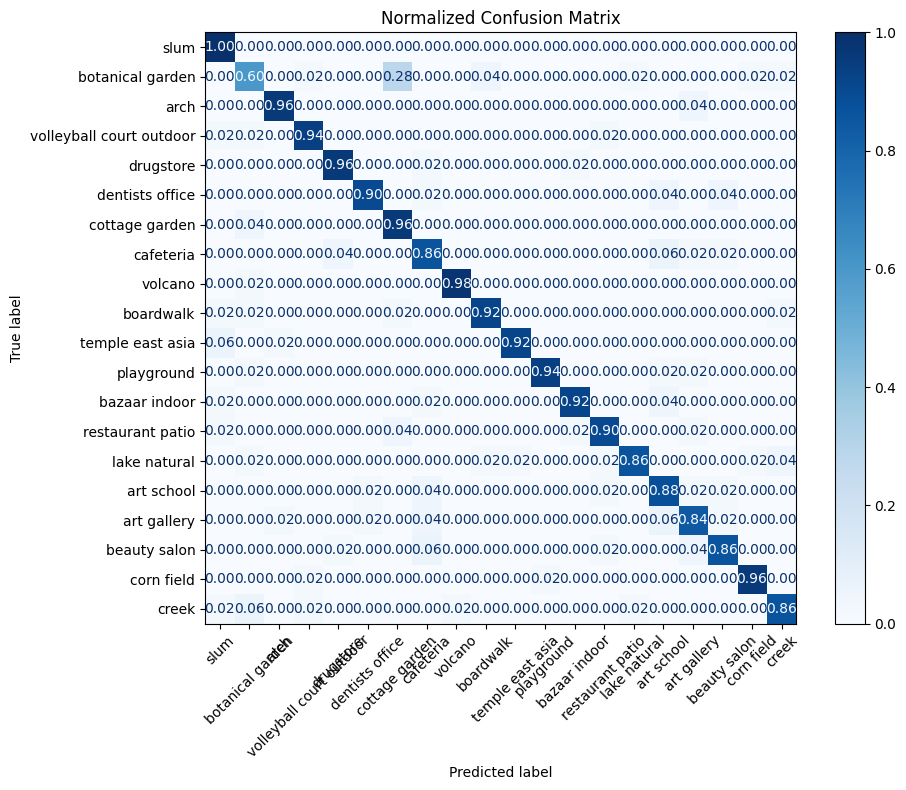

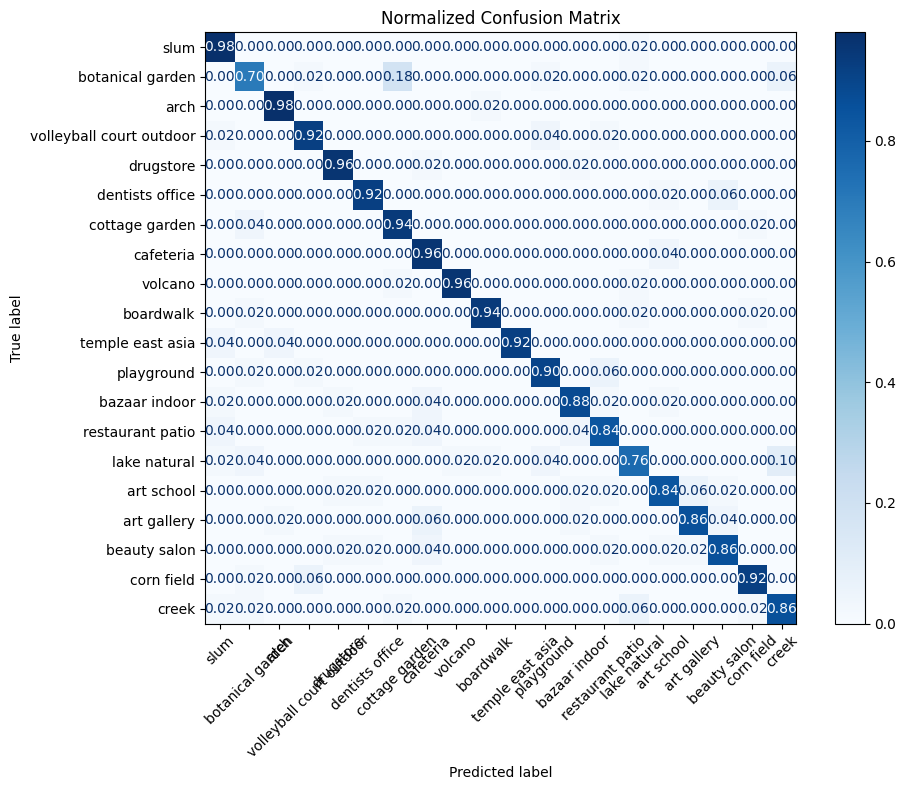

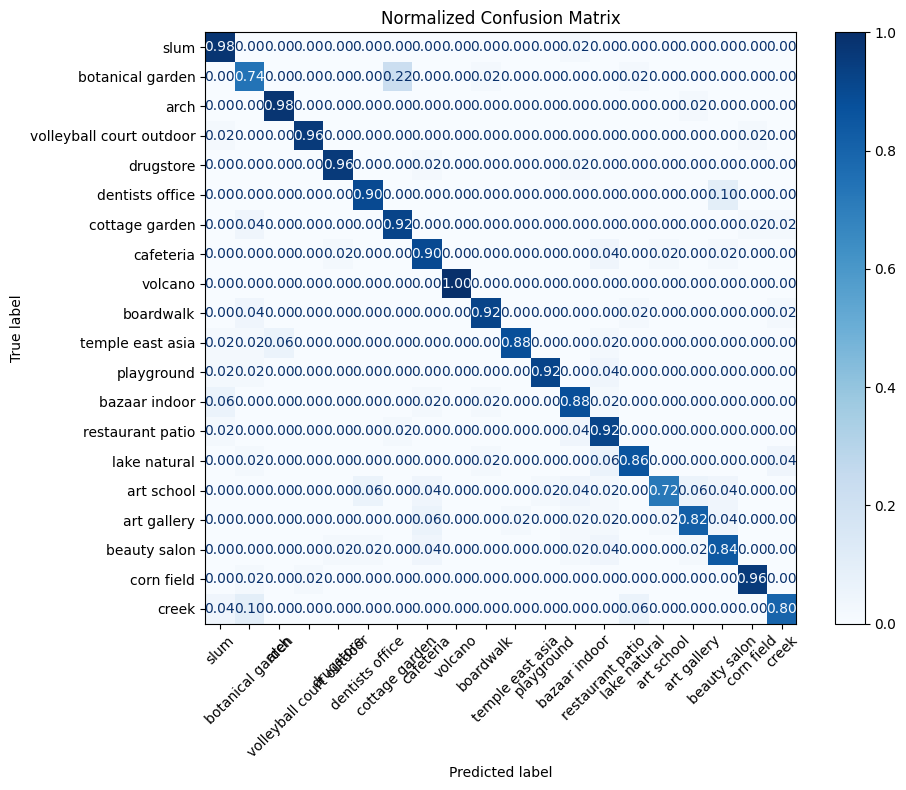

array([[0.98, 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
        0.  , 0.02, 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.  , 0.74, 0.  , 0.  , 0.  , 0.  , 0.22, 0.  , 0.  , 0.02, 0.  ,
        0.  , 0.  , 0.  , 0.02, 0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.  , 0.  , 0.98, 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
        0.  , 0.  , 0.  , 0.  , 0.  , 0.02, 0.  , 0.  , 0.  ],
       [0.02, 0.  , 0.  , 0.96, 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
        0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.02, 0.  ],
       [0.  , 0.  , 0.  , 0.  , 0.96, 0.  , 0.  , 0.02, 0.  , 0.  , 0.  ,
        0.  , 0.02, 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.  , 0.  , 0.  , 0.  , 0.  , 0.9 , 0.  , 0.  , 0.  , 0.  , 0.  ,
        0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.1 , 0.  , 0.  ],
       [0.  , 0.04, 0.  , 0.  , 0.  , 0.  , 0.92, 0.  , 0.  , 0.  , 0.  ,
        0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.02, 0.02],
       [0.  , 0.  , 0.  , 0.  , 0.02, 0. 

In [29]:
#VISUALISE HEATMAP OF CONFUSION MATRIX BETWEEN CLASSES
plot_normalized_confusion_matrix(resnet18, val_loader, classes)
plot_normalized_confusion_matrix(efficientnet_b0, val_loader, classes)
plot_normalized_confusion_matrix(mobilenet_v3, val_loader, classes)

Sampled 1000 images across 20 classes
Features shape: (1000, 512)
Class means shape: (20, 512)


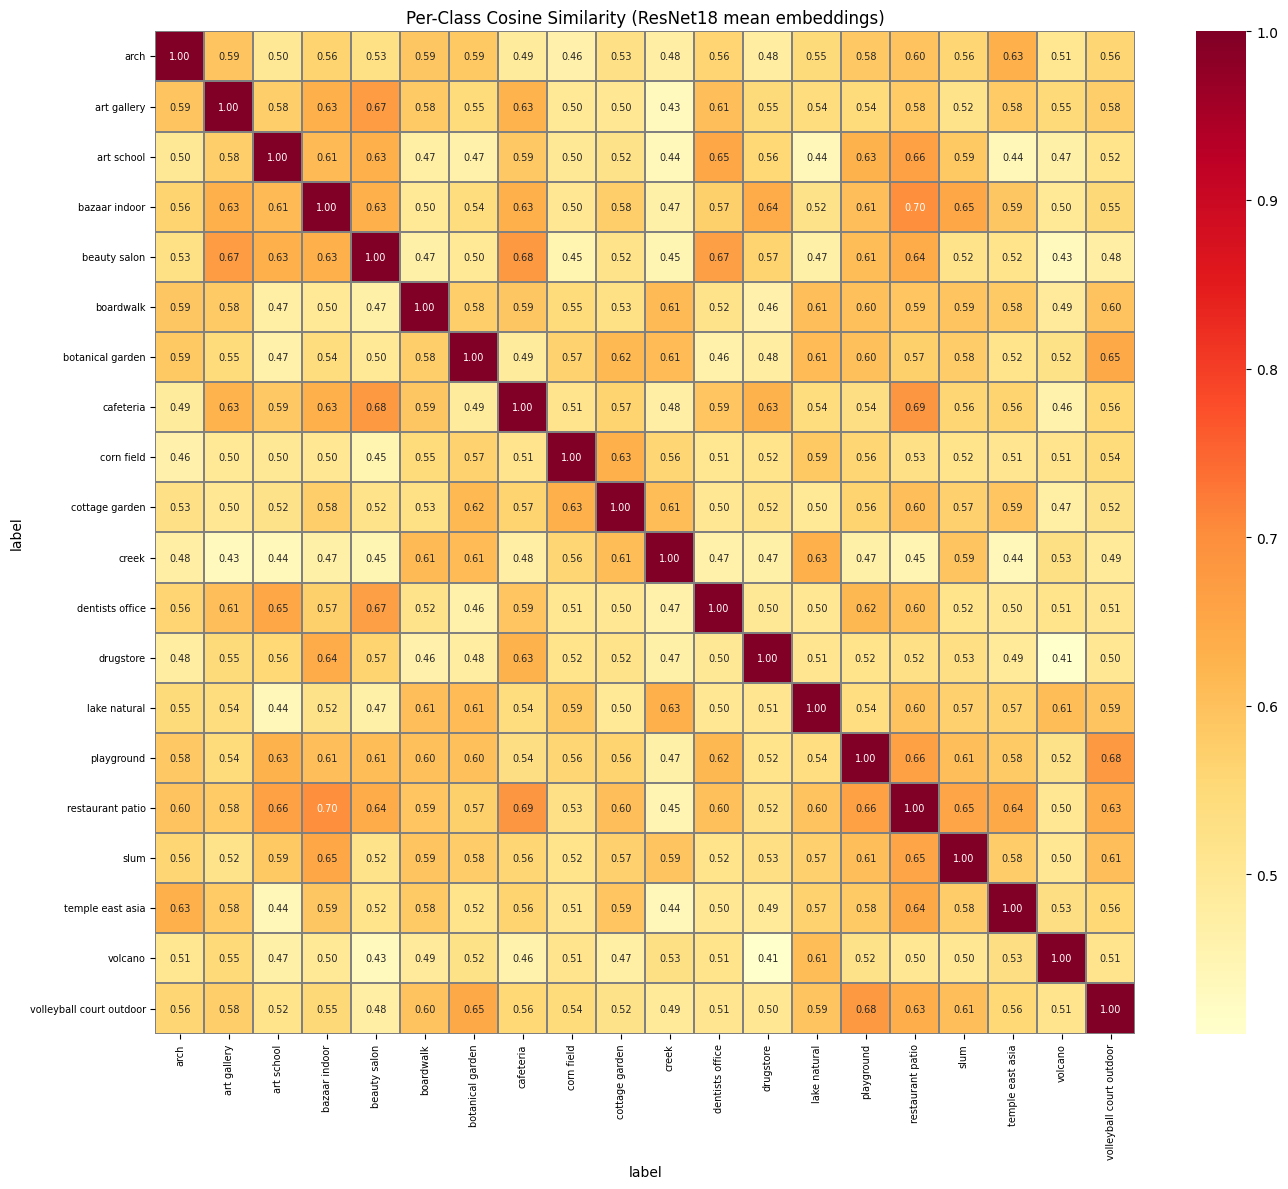

In [30]:
#ResNet
balanced_idx = stratified_sample(subset["train"], n_per_class=50)

features, labels = extract_features(
    resnet18,
    subset["train"],
    balanced_idx,
    class_ids, id_to_label, label_to_id,
    device
)

class_means = compute_class_means(features, labels, subset["train"], class_ids)

sim_df = plot_cosine_similarity(class_means)

Features shape: (1000, 20)
Class means shape: (20, 20)


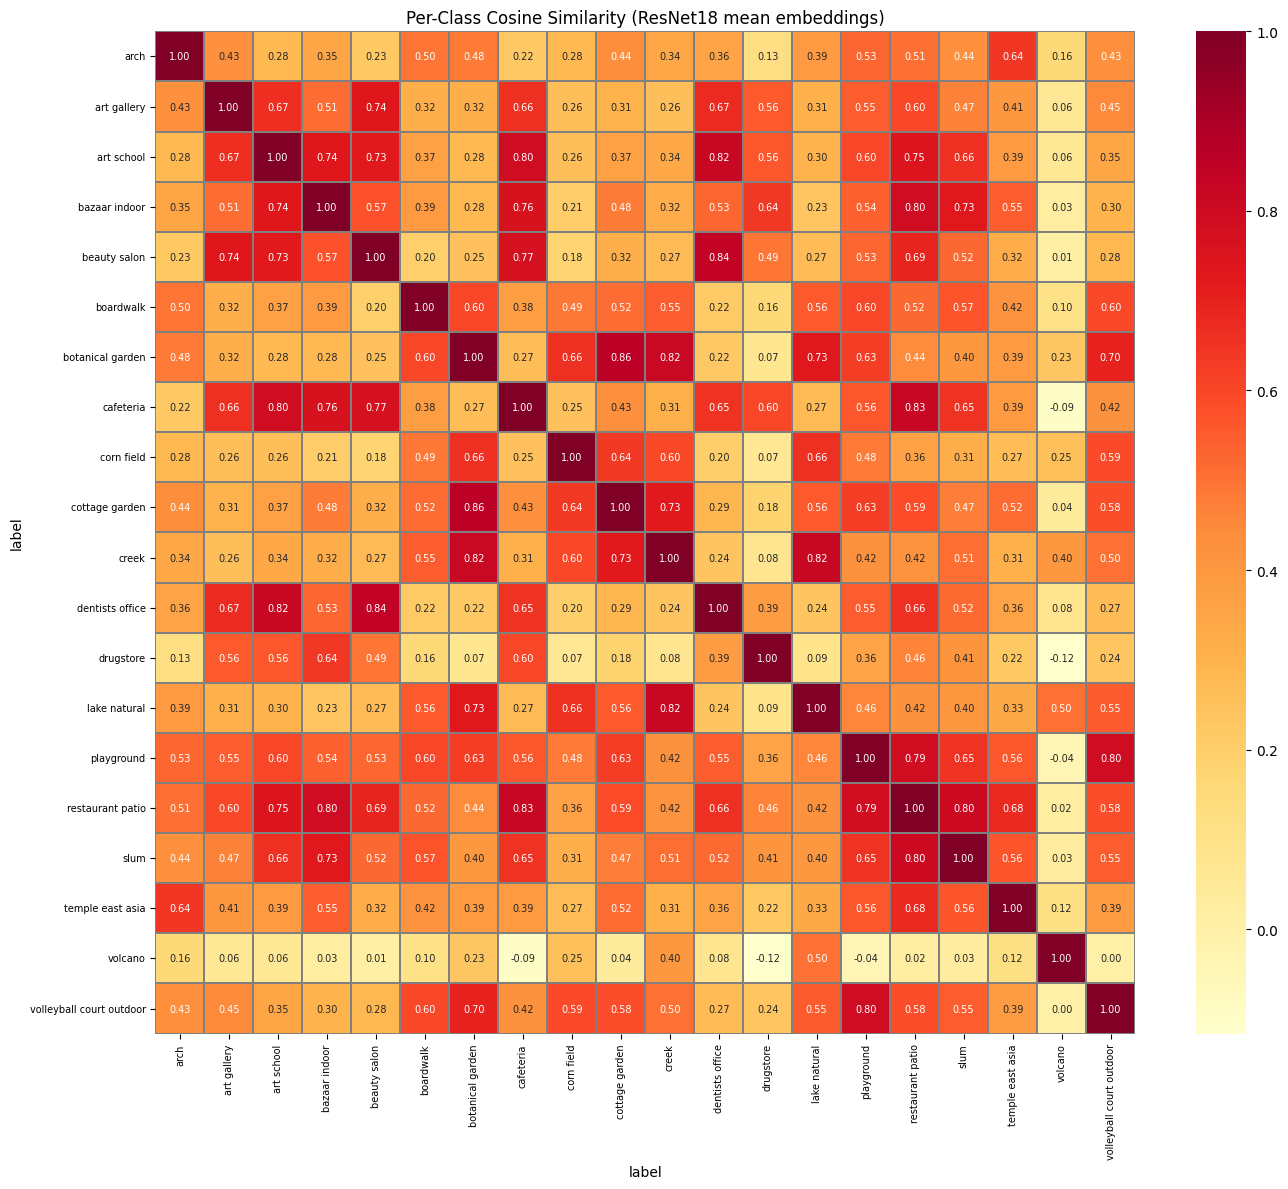

In [31]:
#Efficient-Net
features, labels = extract_features(
    efficientnet_b0,
    subset["train"],
    balanced_idx,
    class_ids, id_to_label, label_to_id,
    device
)

class_means = compute_class_means(features, labels, subset["train"], class_ids)

sim_df = plot_cosine_similarity(class_means)

Features shape: (1000, 20)
Class means shape: (20, 20)


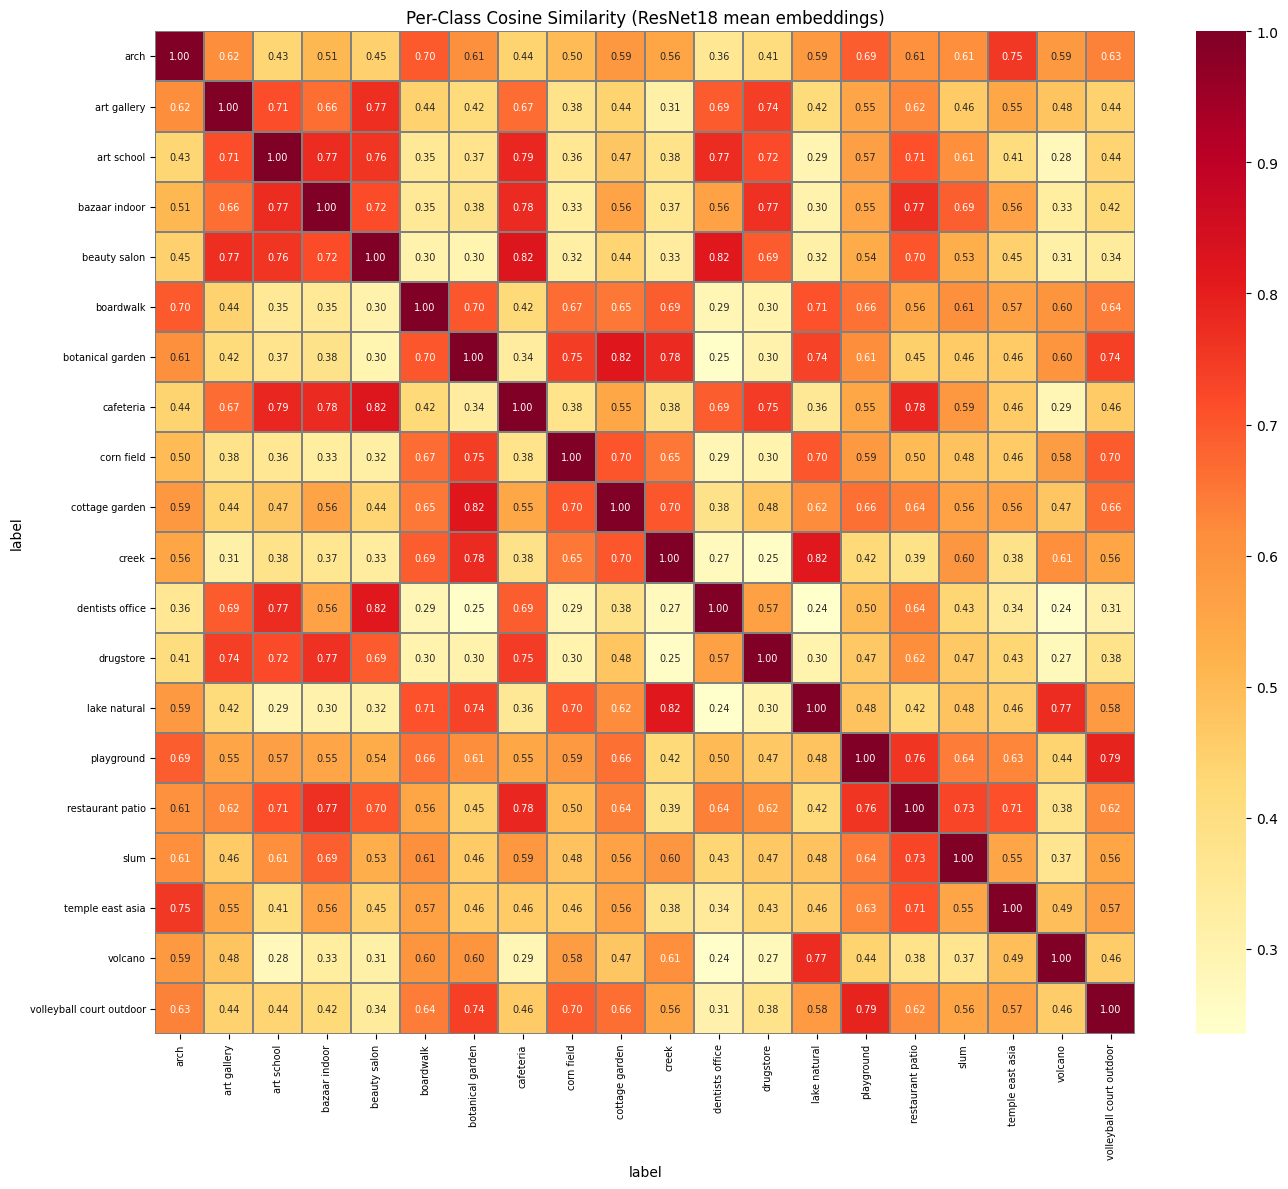

In [32]:
#Mobile-Net
features, labels = extract_features(
    mobilenet_v3,
    subset["train"],
    balanced_idx,
    class_ids, id_to_label, label_to_id,
    device
)

class_means = compute_class_means(features, labels, subset["train"], class_ids)

sim_df = plot_cosine_similarity(class_means)

In [33]:
#SAVE WEIGHTS OF BEST PERFORMING MODEL
os.makedirs("checkpoints", exist_ok=True)

MODEL_PATH = "checkpoints/mobilenet_v3_sun_model.pth"
torch.save(mobilenet_v3.state_dict(), MODEL_PATH)
print("Saved to", MODEL_PATH)

Saved to checkpoints/mobilenet_v3_sun_model.pth


In [38]:
#LOG INTO HUGGING FACE
!pip install -q huggingface_hub

from huggingface_hub import notebook_login
notebook_login()  # will open a widget to paste your HF token

from huggingface_hub import login

#login(token="INSERT_TOKEN")

In [39]:
def upload_model(model, model_name, classifier_key, folder_name):
    """
    Save weights + config for one model and push to HuggingFace Hub.

    Args:
        model          : trained PyTorch model
        model_name     : string name written into config.json
        classifier_key : "fc" for ResNet, "classifier" for Efficient/Mobile
        folder_name    : subfolder name inside the repo
    """
    # Save weights locally
    os.makedirs("checkpoints", exist_ok=True)
    weights_path = f"checkpoints/{folder_name}.pth"
    torch.save(model.state_dict(), weights_path)

    # Build upload folder
    model_dir = folder_name
    os.makedirs(model_dir, exist_ok=True)
    shutil.copy(weights_path, os.path.join(model_dir, "pytorch_model.bin"))

    config = {
        "model_type":  model_name,
        "num_classes": 10,
        "id_to_label": {str(i): name for i, name in enumerate(classes)},
        "label_to_id": {name: i for i, name in enumerate(classes)},
    }

    with open(os.path.join(model_dir, "config.json"), "w") as f:
        json.dump(config, f, indent=2)

    # Upload this model's folder as a subfolder in the repo
    upload_folder(
        repo_id=repo_id,
        folder_path=model_dir,
        path_in_repo=folder_name,          # places it in a subfolder in the repo
        commit_message=f"Add {model_name} weights",
    )
    print(f"Uploaded {model_name} to {repo_id}/{folder_name}")

In [42]:
#PUSH FOLDER TO HUGGING FACE HUB
from huggingface_hub import create_repo, upload_folder

repo_id = "SharmarkeO/sun10-scene-classifier"  # change to your HF handle

# Create repo if it doesn't exist (public by default)
create_repo(repo_id, exist_ok=True)

# ── Upload all three ──
upload_model(resnet18, "resnet18", "fc", "resnet18")
upload_model(efficientnet_b0, "efficientnet_b0", "classifier", "efficientnet_b0")
upload_model(mobilenet_v3, "mobilenet_v3_large", "classifier", "mobilenet_v3")

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...esnet18/pytorch_model.bin:   3%|2         | 1.13MB / 44.8MB            

Uploaded resnet18 to SharmarkeO/sun10-scene-classifier/resnet18


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

...

Uploaded efficientnet_b0 to SharmarkeO/sun10-scene-classifier/efficientnet_b0


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...enet_v3/pytorch_model.bin:  23%|##2       | 3.87MB / 17.1MB            

Uploaded mobilenet_v3_large to SharmarkeO/sun10-scene-classifier/mobilenet_v3
